# Week 1 Challenge Project Template

You are not required to use this template, but we are providing it for your reference to help get you started and stay organized!  We recommend that you define functions for each step to make it easier to track what's going on in the code (especially if different team members are working on different pieces of the project).

Most of the functions provided are just examples!  Feel free to replace them with something better!  This is just a minimum working example.

## 1. Load the data

In [99]:
import pandas as po
import numpy as np

%matplotlib inline

In [100]:
train_url = "https://raw.githubusercontent.com/MedlyticsUniversal/Data/main/Week1/allhypo.train.csv"
test_url = "https://raw.githubusercontent.com/MedlyticsUniversal/Data/main/Week1/allhypo.test.csv"

data_train = po.read_csv(train_url) 
data_test = po.read_csv(test_url)   # this will not have a 'class' column!

if 'Class' in data_train.columns:
    data_train = data_train.rename(columns={'Class': 'class'})
    print("✓ Fixed column name: 'Class' → 'class'")

# identify columns by what time of data they hold
numeric_columns=list(["Age","TSH","T3","TT4","T4U","FTI"])

# categorical columns are everything else (minus 'class')
categorical_columns = list(set(data_train.columns)-set(numeric_columns)-set(['class']))

✓ Fixed column name: 'Class' → 'class'


## 2. Format your class labels
Turn multi-classes into binary classes

In [101]:
def format_class_labels(df):
    
    import re 
    
    # regex the weird class labels out
    regex_pattern = r"\.\|\d+"

    for index, row in df.iterrows():

        # substitute instances of our regex_pattern for an empty string
        new_class = re.sub(regex_pattern, '', row['class'])
        df.loc[index,'class']=new_class
    
    # set all negative class labels to 0, all others to 1

    df['class'] = df['class'].replace('negative', 0)                    
    df['class'] = df['class'].replace('compensated hypothyroid', 1)     
    df['class'] = df['class'].replace('primary hypothyroid', 1)         
    df['class'] = df['class'].replace('secondary hypothyroid', 1)
    
    return df

data_train = format_class_labels(data_train)
data_train.head()

/tmp/ipykernel_1749/2751186566.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['class'] = df['class'].replace('secondary hypothyroid', 1)


,Age,Sex,On Thyroxine,Query on Thyroxine,On Antithyroid Medication,Sick,Pregnant,Thyroid Surgery,I131 Treatment,Query Hypothyroid,...,TT4 Measured,TT4,T4U Measured,T4U,FTI Measured,FTI,TBG Measured,TBG,Referral Source,class
0,41,F,f,f,f,f,f,f,f,f,...,t,125,t,1.14,t,109,f,?,SVHC,0
1,23,F,f,f,f,f,f,f,f,f,...,t,102,f,?,f,?,f,?,other,0
2,46,M,f,f,f,f,f,f,f,f,...,t,109,t,0.91,t,120,f,?,other,0
3,70,F,t,f,f,f,f,f,f,f,...,t,175,f,?,f,?,f,?,other,0
4,70,F,f,f,f,f,f,f,f,f,...,t,61,t,0.87,t,70,f,?,SVI,0


## 3. Split training into training and validation
Choose what split you like (alternatively, you can do k-fold cross validation)

In [102]:
from sklearn.model_selection import train_test_split

data_train, data_val = train_test_split(data_train, test_size=0.20, random_state=0, stratify=data_train['class'])

## 4. Clean/format the data
Note: removing rows is probably a bad idea because you won't be able to do this to the test data!  Try to come up with some clever ways to handle the "?" values.

In [103]:
def clean_missing(df, numeric_columns, fill_from=None):
    """Replace '?' with NaN and impute using median (numeric) or mode (categorical)."""
    df = df.copy()
    source = fill_from if fill_from is not None else df

    for col in numeric_columns:
        if col not in df.columns:
            continue
        df[col] = po.to_numeric(df[col].replace('?', np.nan), errors='coerce')
        fill_value = source[col].median() if col in source.columns else df[col].median()
        df[col] = df[col].fillna(fill_value)

    for col in df.columns:
        if col in numeric_columns or col == 'class':
            continue
        if fill_from is not None and col not in source.columns:
            continue
        df[col] = df[col].replace('?', np.nan)
        modes = source[col].mode(dropna=True) if col in source.columns else df[col].mode(dropna=True)
        mode_val = modes.iloc[0] if len(modes) > 0 else 'f'
        df[col] = df[col].fillna(mode_val)

    return df


# Make sure you do the same thing to train, val & test
data_train = clean_missing(data_train, numeric_columns)
data_val = clean_missing(data_val, numeric_columns, fill_from=data_train)
data_test = clean_missing(data_test, numeric_columns, fill_from=data_train)

/tmp/ipykernel_1749/4129698602.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace('?', np.nan)


In [104]:
def get_uninformative_columns(df):
    
    drop_columns = []
    
    for col in df.columns:
        
        # if this column has only one value, we can't learn anything from it
        if(len(df[col].unique()) == 1):
            drop_columns.append(col)
            
    return drop_columns


# drop the uninformative features
drop_columns = get_uninformative_columns(data_train)

# Make sure you do the same thing to train, val & test
data_train=data_train.drop(drop_columns,axis=1)
data_val=data_val.drop(drop_columns,axis=1)
data_test=data_test.drop(drop_columns,axis=1)





In [105]:
# clean_missing is defined and applied in the cell above

In [106]:
def format_data(df, numeric_columns, fill_from=None):
    df = df.copy()
    source = fill_from if fill_from is not None else df

    for col in numeric_columns:
        if col not in df.columns:
            continue
        df[col] = po.to_numeric(df[col].replace('?', np.nan), errors='coerce')
        if df[col].isna().any():
            fill_value = source[col].median() if col in source.columns else df[col].median()
            df[col] = df[col].fillna(fill_value)

    categorical_columns = list(set(df.columns) - set(numeric_columns) - set(['class']))

    for col in categorical_columns:
        df[col] = df[col].replace('?', np.nan)
        if df[col].isna().any():
            modes = source[col].mode(dropna=True) if col in source.columns else df[col].mode(dropna=True)
            mode_val = modes.iloc[0] if len(modes) > 0 else 'f'
            df[col] = df[col].fillna(mode_val)

    if categorical_columns:
        dummies = po.get_dummies(df[categorical_columns], drop_first=True)
        df = df.drop(columns=categorical_columns)
        df = po.concat([df, dummies], axis=1)

    # align dummy columns to training data (get_dummies can differ across splits)
    if fill_from is not None:
        feature_cols = [c for c in fill_from.columns if c != 'class']
        for col in feature_cols:
            if col not in df.columns:
                df[col] = 0
        extra_cols = [c for c in df.columns if c not in fill_from.columns and c != 'class']
        if extra_cols:
            df = df.drop(columns=extra_cols)

    return df


# Make sure you do the same thing to train & val
data_train = format_data(data_train, numeric_columns)
data_val = format_data(data_val, numeric_columns, fill_from=data_train)

## 5. Define and Train the Model
You might want to consider having one process for training on one dataset and evaluating on another.  That way you can use the same code for your train/validation as you do for your train/test

In [107]:
def my_classifier_predictions(data_train, data_predict):

    feature_columns = list(set(data_train.columns)-set(['class']))

    X_train = data_train[feature_columns]
    y_train = data_train['class']

    X_val = data_predict.copy()
    for col in feature_columns:
        if col not in X_val.columns:
            X_val[col] = 0
    X_val = X_val[feature_columns]
    
    # For now, we'll just do logistic regression
    from sklearn.linear_model import LogisticRegression
    lr_model = LogisticRegression()

    # fit the model to training data 
    lr_model.fit(X_train, y_train)

    # apply the model to evaluation data
    y_proba = lr_model.predict_proba(X_val)
    
    return y_proba


print("In train but not val:", set(data_train.columns) - set(data_val.columns))
print("In val but not train:", set(data_val.columns) - set(data_train.columns))
    

In train but not val: set()
In val but not train: set()


In [108]:
# Predict on validation data
y_val_proba = my_classifier_predictions(data_train, data_val)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 6. Evaluate your model

### Confusion Matrix Metric

In [109]:
from sklearn.metrics import confusion_matrix

# evaluate on validation set
y_val = data_val['class']

# This is exctly the first metric you'll be evaluated on!
# Note: this will only work on the binary case -- let us know if you get to the multi-class case

def cm_metric(y_true,y_prob):
    
    # predict the class with the greatest probability
    y_val_predict = [np.argmax(y) for y in y_prob]

    # calculate the confusion matrix
    cm = confusion_matrix(y_true, y_val_predict)

    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    print(cm_norm)
    return sum(sum(np.multiply(cm_norm,np.array([[1, -2], [-2, 1]]))))

print('Confusion Matrix Metric: ',cm_metric(y_val,y_val_proba))

[[0.99612403 0.00387597]
 [0.45454545 0.54545455]]
Confusion Matrix Metric:  0.6247357293868921


### AUC

In [110]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

fpr, tpr, threshold = roc_curve(y_val, y_val_proba[:,1])
roc_auc = auc(fpr, tpr)
print('AUC: ',roc_auc)



AUC:  0.9905743481324876


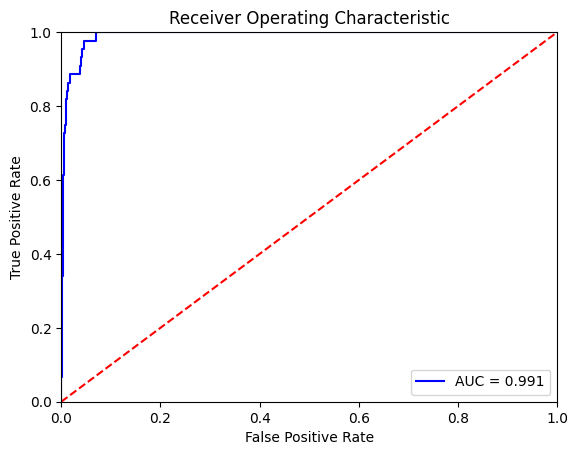

In [111]:
import matplotlib.pyplot as plt
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.3f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

## Feature selection

Train a Random Forest to rank feature importance (TSH should dominate clinically). Use the plot below to see which attributes matter most, then use drop-one testing in the next cell to find a smaller feature set.

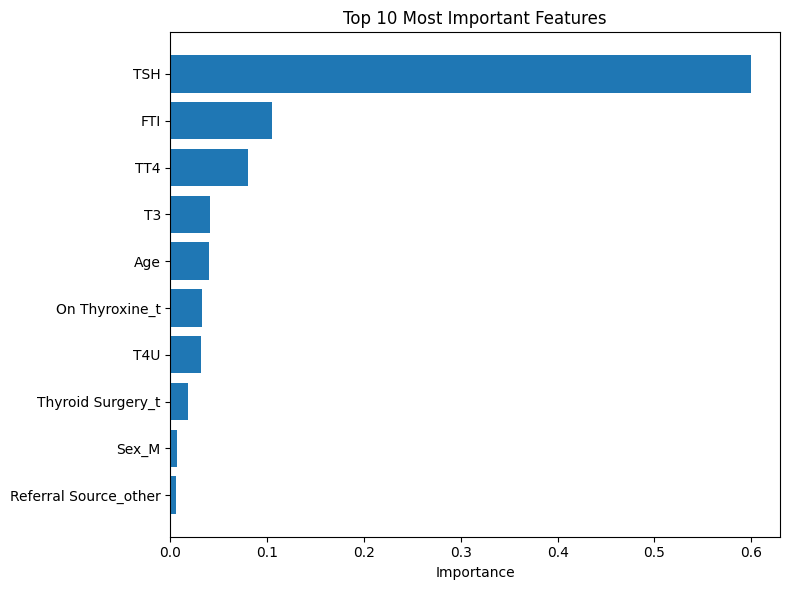

Top 10 feature importances:
              feature  importance
                  TSH      0.5997
                  FTI      0.1051
                  TT4      0.0805
                   T3      0.0411
                  Age      0.0401
       On Thyroxine_t      0.0326
                  T4U      0.0317
    Thyroid Surgery_t      0.0186
                Sex_M      0.0065
Referral Source_other      0.0054


In [112]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

feature_columns = [c for c in data_train.columns if c != 'class']
X_train = data_train[feature_columns]
y_train = data_train['class']

rf_model = RandomForestClassifier(n_estimators=100, random_state=0)
rf_model.fit(X_train, y_train)

importance_df = po.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_,
}).sort_values('importance', ascending=False)

top_n = 10
top_features = importance_df.head(top_n)

plt.figure(figsize=(8, 6))
plt.barh(top_features['feature'][::-1], top_features['importance'][::-1])
plt.xlabel('Importance')
plt.title('Top 10 Most Important Features')
plt.tight_layout()
plt.show()

print('Top 10 feature importances:')
print(top_features.to_string(index=False, float_format='%.4f'))

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_val_rf = data_val['class']
y_val_pred_rf = rf_model.predict(data_val[feature_columns])

cm = confusion_matrix(y_val_rf, y_val_pred_rf)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax)

classes = ['0', '1']
tick_marks = np.arange(len(classes))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
ax.set_title('Normalized Random Forest Confusion Matrix')

thresh = cm_norm.max() / 2.0
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        ax.text(
            j, i, format(cm_norm[i, j], '.3g'),
            ha='center', va='center',
            color='white' if cm_norm[i, j] > thresh else 'black',
        )

plt.tight_layout()
plt.show()

rf_cm_metric = sum(sum(np.multiply(cm_norm, np.array([[1, -2], [-2, 1]]))))
rf_accuracy = accuracy_score(y_val_rf, y_val_pred_rf)

print('Confusion Matrix Metric:', rf_cm_metric)
print(f'Validation accuracy: {rf_accuracy * 100:.1f}%')

In [113]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

METRIC_DROP_THRESHOLD = 0.02  # treat a drop larger than this as "important"


def predict_with_features(data_train, data_predict, feature_columns):
    """Train logistic regression on a feature subset and return probabilities + fitted model."""
    feature_columns = list(feature_columns)
    X_train = data_train[feature_columns]
    y_train = data_train['class']

    X_val = data_predict.copy()
    for col in feature_columns:
        if col not in X_val.columns:
            X_val[col] = 0
    X_val = X_val[feature_columns]

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    return model.predict_proba(X_val), model


def cm_metric_value(y_true, y_prob):
    """Same confusion-matrix metric as cm_metric, without printing."""
    y_predict = [np.argmax(y) for y in y_prob]
    cm = confusion_matrix(y_true, y_predict)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    metric = sum(sum(np.multiply(cm_norm, np.array([[1, -2], [-2, 1]]))))
    specificity = cm_norm[0, 0]
    sensitivity = cm_norm[1, 1]
    return metric, sensitivity, specificity, cm_norm


def evaluate_feature_set(feature_columns, data_train, data_val, y_val):
    y_prob, model = predict_with_features(data_train, data_val, feature_columns)
    metric, sensitivity, specificity, cm_norm = cm_metric_value(y_val, y_prob)
    fpr, tpr, _ = roc_curve(y_val, [p[1] for p in y_prob])
    auc_score = auc(fpr, tpr)
    return {
        'features': list(feature_columns),
        'metric': metric,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'auc': auc_score,
        'cm_norm': cm_norm,
        'y_prob': y_prob,
        'model': model,
    }


all_features = sorted(set(data_train.columns) - {'class'})
y_val = data_val['class']

# --- 1) Print weights for the full model ---
print('=' * 60)
print('LOGISTIC REGRESSION WEIGHTS (full model)')
print('=' * 60)
full_result = evaluate_feature_set(all_features, data_train, data_val, y_val)
weights = full_result['model'].coef_[0]
weight_table = sorted(zip(all_features, weights), key=lambda x: abs(x[1]), reverse=True)
for feat, w in weight_table:
    print(f'  {feat:30s}  weight={w:+.4f}  |weight|={abs(w):.4f}')

print(f"\nBaseline ({len(all_features)} features):")
print(f"  cm_metric={full_result['metric']:.4f}")
print(f"  sensitivity={full_result['sensitivity']:.4f}")
print(f"  specificity={full_result['specificity']:.4f}")
print(f"  AUC={full_result['auc']:.4f}")

# --- 2) Drop-one check: remove each feature one at a time ---
print('\n' + '=' * 60)
print('DROP-ONE CHECK (remove 1 feature, then measure metric)')
print('=' * 60)
baseline_metric = full_result['metric']
drop_one_results = []

for feat in all_features:
    trial_features = [f for f in all_features if f != feat]
    result = evaluate_feature_set(trial_features, data_train, data_val, y_val)
    change = result['metric'] - baseline_metric
    drop = baseline_metric - result['metric']
    status = 'IMPORTANT (big drop)' if drop > METRIC_DROP_THRESHOLD else 'can likely drop'
    print(f"  drop {feat:30s}  metric={result['metric']:.4f}  change={change:+.4f}  -> {status}")
    drop_one_results.append((feat, result['metric'], drop, status))

# --- 3) Greedy backward elimination ---
print('\n' + '=' * 60)
print('BACKWARD ELIMINATION (repeatedly drop least-harmful feature)')
print('=' * 60)

current_features = all_features.copy()
current_result = full_result
best_result = full_result
elimination_history = []

while len(current_features) > 1:
    candidates = []
    for feat in current_features:
        trial_features = [f for f in current_features if f != feat]
        result = evaluate_feature_set(trial_features, data_train, data_val, y_val)
        drop = current_result['metric'] - result['metric']
        candidates.append((feat, result, drop))

    # drop the feature whose removal hurts the metric the least
    feat_to_drop, new_result, drop_amount = min(candidates, key=lambda x: x[2])

    if drop_amount > METRIC_DROP_THRESHOLD:
        important = max(candidates, key=lambda x: x[2])
        print(f"Stopping: dropping '{important[0]}' would reduce metric by {important[2]:.4f} (important feature)")
        break

    current_features.remove(feat_to_drop)
    current_result = new_result
    elimination_history.append((feat_to_drop, new_result))

    if new_result['metric'] >= best_result['metric']:
        best_result = new_result

    print(
        f"Dropped '{feat_to_drop}' -> {len(current_features)} features, "
        f"metric={new_result['metric']:.4f}, sens={new_result['sensitivity']:.4f}, "
        f"spec={new_result['specificity']:.4f}"
    )

# --- 4) Best combination ---
print('\n' + '=' * 60)
print('BEST FEATURE COMBINATION')
print('=' * 60)
print(f"Feature count: {len(best_result['features'])}")
print(f"cm_metric:     {best_result['metric']:.4f}")
print(f"sensitivity:   {best_result['sensitivity']:.4f}")
print(f"specificity:   {best_result['specificity']:.4f}")
print(f"AUC:           {best_result['auc']:.4f}")
print('\nFeatures:')
for feat in sorted(best_result['features']):
    print(f'  - {feat}')

print('\nWeights for best combo:')
best_weights = sorted(
    zip(best_result['features'], best_result['model'].coef_[0]),
    key=lambda x: abs(x[1]),
    reverse=True,
)
for feat, w in best_weights:
    print(f'  {feat:30s}  weight={w:+.4f}  |weight|={abs(w):.4f}')

LOGISTIC REGRESSION WEIGHTS (full model)


  On Thyroxine_t                  weight=-3.3830  |weight|=3.3830
  Thyroid Surgery_t               weight=-3.3434  |weight|=3.3434
  TSH Measured_t                  weight=+1.5608  |weight|=1.5608
  T4U                             weight=+0.6144  |weight|=0.6144
  Tumor_t                         weight=+0.5942  |weight|=0.5942
  Pregnant_t                      weight=-0.5051  |weight|=0.5051
  TT4 Measured_t                  weight=+0.5008  |weight|=0.5008
  Psych_t                         weight=+0.4887  |weight|=0.4887
  On Antithyroid Medication_t     weight=-0.4803  |weight|=0.4803
  T3 Measured_t                   weight=-0.4598  |weight|=0.4598
  Goiter_t                        weight=-0.4494  |weight|=0.4494
  T3                              weight=-0.4490  |weight|=0.4490
  Referral Source_SVHC            weight=-0.4211  |weight|=0.4211
  Sick_t                          weight=+0.3150  |weight|=0.3150
  TSH                             weight=+0.3149  |weight|=0.3149
  Lithium_

## 7. Apply to test data
Once you're happy with your model, you should go through the same procedure again except:
* train with ALL the training data (re-combine with training and validation)
* test on test data (you won't be able to evaluate -- that's for us to do!)

In [114]:
train_url = "https://raw.githubusercontent.com/BeaverWorksMedlytics/datasets/master/allhypo.train.data.csv"
test_url = "https://raw.githubusercontent.com/BeaverWorksMedlytics/datasets/master/allhypo.test.data.csv"

data_train = po.read_csv(train_url) 
data_test = po.read_csv(test_url)   # this will not have a 'class' column!

# format the wonky class labels
data_train = format_class_labels(data_train)

# deal with question marks
data_train = clean_missing(data_train, numeric_columns)
data_test = clean_missing(data_test, numeric_columns, fill_from=data_train)

# drop uninformative columns
drop_columns = get_uninformative_columns(data_train)
data_train=data_train.drop(drop_columns,axis=1)
data_test=data_test.drop(drop_columns,axis=1)

# format data
data_train = format_data(data_train, numeric_columns)
data_test = format_data(data_test, numeric_columns, fill_from=data_train)

# train and apply your classifier
y_test_proba = my_classifier_predictions(data_train, data_test)

HTTPError: HTTP Error 404: Not Found

## 8. Submit your attempt!

Once you've run on the test data, send a pickle file containing your predictions contained a pandas dataframe.  This pandas dataframe will contain two columns for your binary classifier (or 4 columns for the multiclass classifier) that looks like this (*pay attention to the column names!*):

|   | 0 | 1   |
|---|---|------|
| 0 | $p_{0,0}$ | $p_{0,1}$|
| 1 | $p_{1,0}$ | $p_{1,1}$|
| 2 | $p_{2,0}$ | $p_{2,1}$|
| ... | ... | ...|
| N | $p_{N,0}$ | $p_{N,1}$|

where $p_{i,j}$ corresponds to the probability of data point $i$ belonging to class $j$.

In [ ]:
from google.colab import files
import pickle

# create a pickle file (this will save to the Google cloud)
prediction_pickle_path = 'teamname_week1_attempt1.pkl'
prediction_pickle = open(prediction_pickle_path, 'wb')
pickle.dump(y_test_proba, prediction_pickle)

# download the pickle file and save it somewhere to your computer, and email it to 
files.download(prediction_pickle_path)
prediction_pickle.close()

# Moving to the Next Level

For those that finish early, remember how I converted the class values into simply "negative" and "positive"? Now try tackling the multiclass classifier (predicting the different types of positive hypothyroid cases instead of simply negative or positive)! 

The same rules apply!  (Note: for the multiclass problem, the AUC calculation will be the micro-average over your classes.)